[2026-08-05 13:47:24] [info     ] 计算因子，区间：2024-01-01 00:00:00 ~ 2024-12-31 23:59:59
[2026-08-05 13:47:29] [info     ] 读取因子库，区间：2024-01-01 00:00:00 ~ 2024-12-31 23:59:59
[2026-08-05 13:47:29] [warning  ] bigalpha_eval._latest version='v4' (use ._latest for dev only, not for prod)
[2026-08-05 13:47:32] [info     ] bigalpha_eval.v4 开始运行 ..
[2026-08-05 13:47:33] [warning  ] 未传入官方评估窗口 start_date/end_date，回退到数据自身范围（仅建议本地调试时使用）
[2026-08-05 13:47:33] [info     ] 对齐中证1000历史成分后，官方评估窗口: 2024-01-02 至 2024-12-31
[2026-08-05 13:47:33] [info     ] ========== 数据检查 ==========
[2026-08-05 13:47:33] [info     ] 通过：列名检查（date/instrument + 至少 1 个因子列） factor_cols=['factor', 'close', 'volume', 'amount', 'turn', 'change_ratio', 'daily_return', 'momentum_5', 'reversal_5', 'volatility_5', 'total_market_cap', 'float_market_cap', 'pe_ttm', 'pb', 'ps_ttm', 'sma_20', 'ema_20', 'macd_diff_12_26_9', 'macd_dea_12_26_9', 'macd_hist_12_26_9', 'rsi_12', 'kdj_k_9_3_3', 'kdj_d_9_3_3', 'bias_20', 'cci_14', 'atr_14', 'roe_avg

时段,IC
2024-01-15~2024-02-08,-0.0033
2024-09-24~2024-10-08,-0.0062

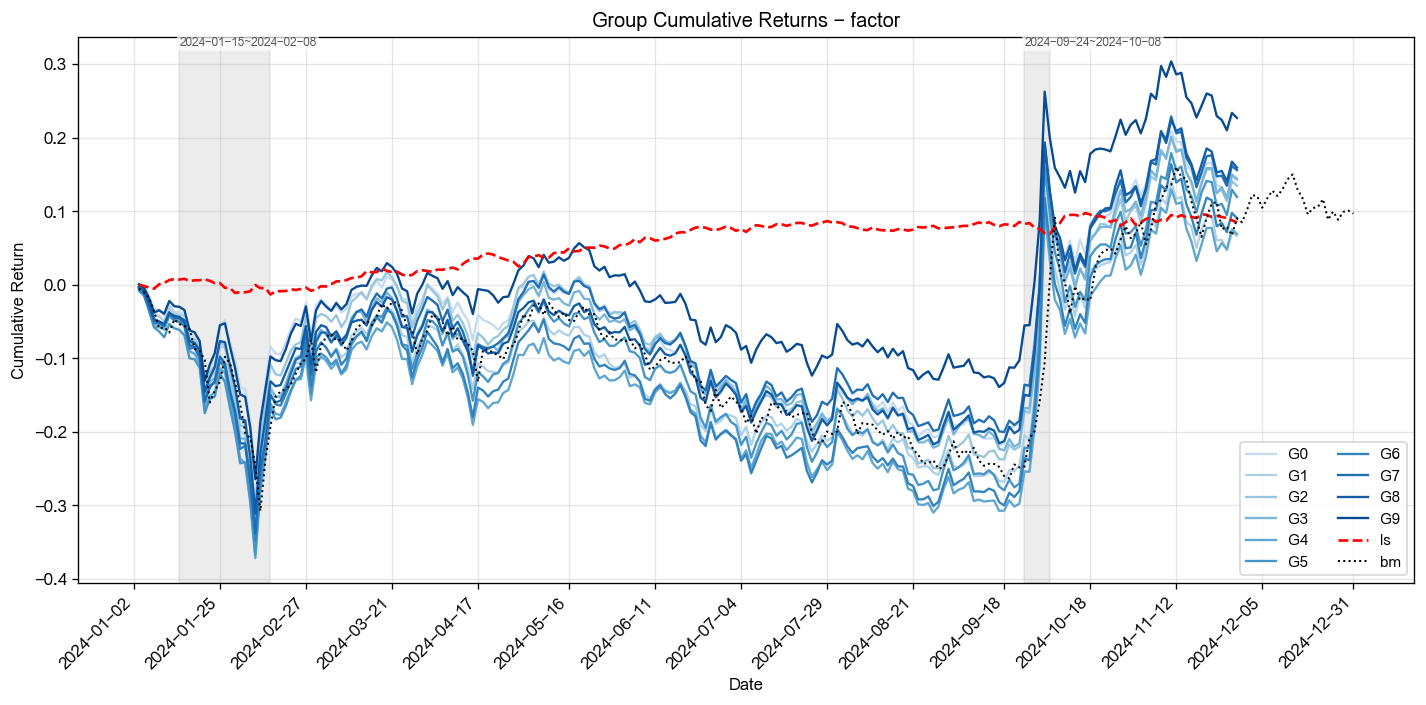
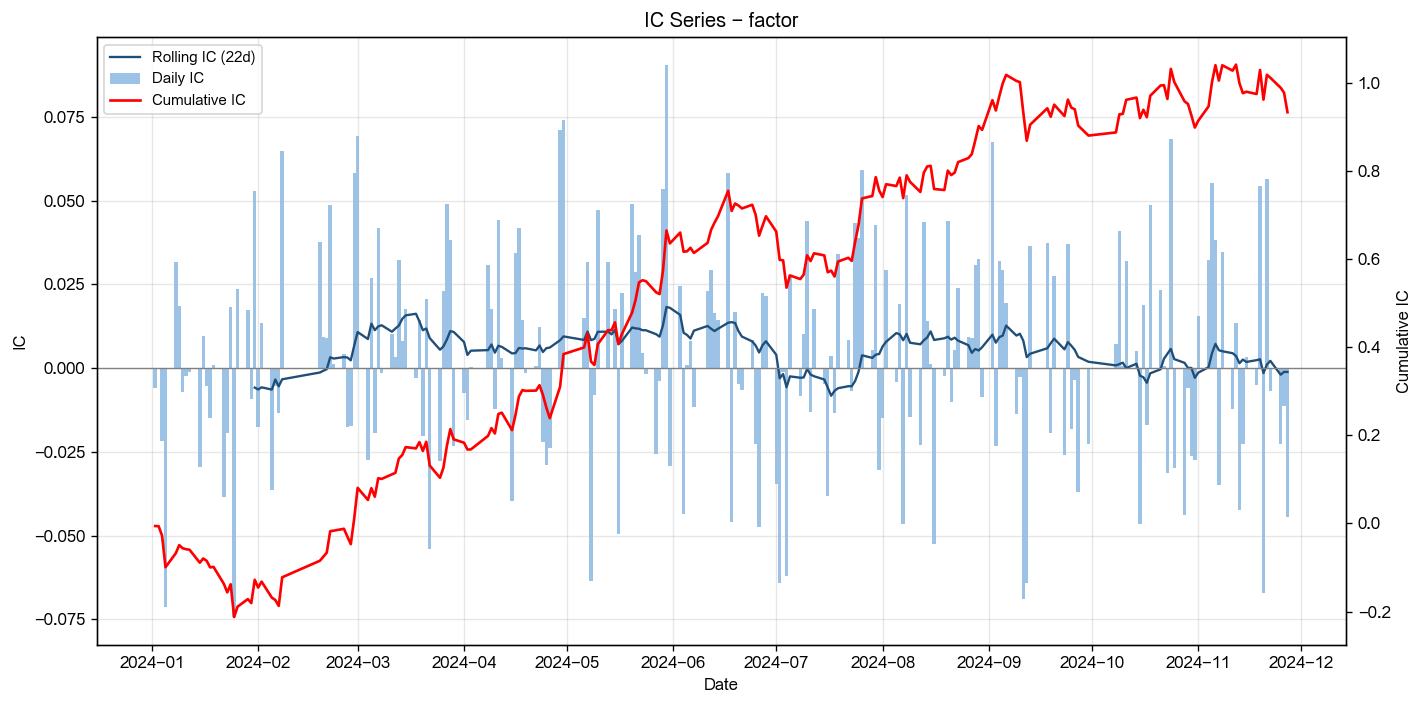
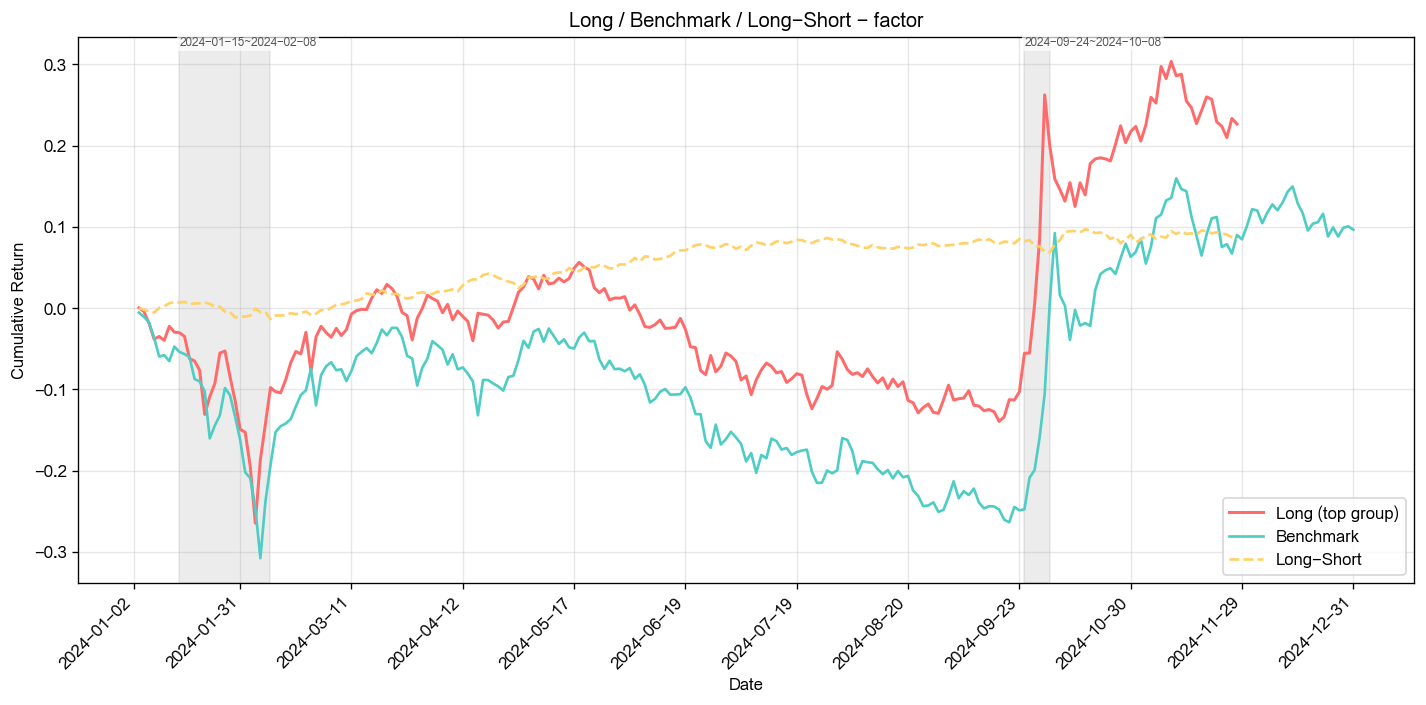
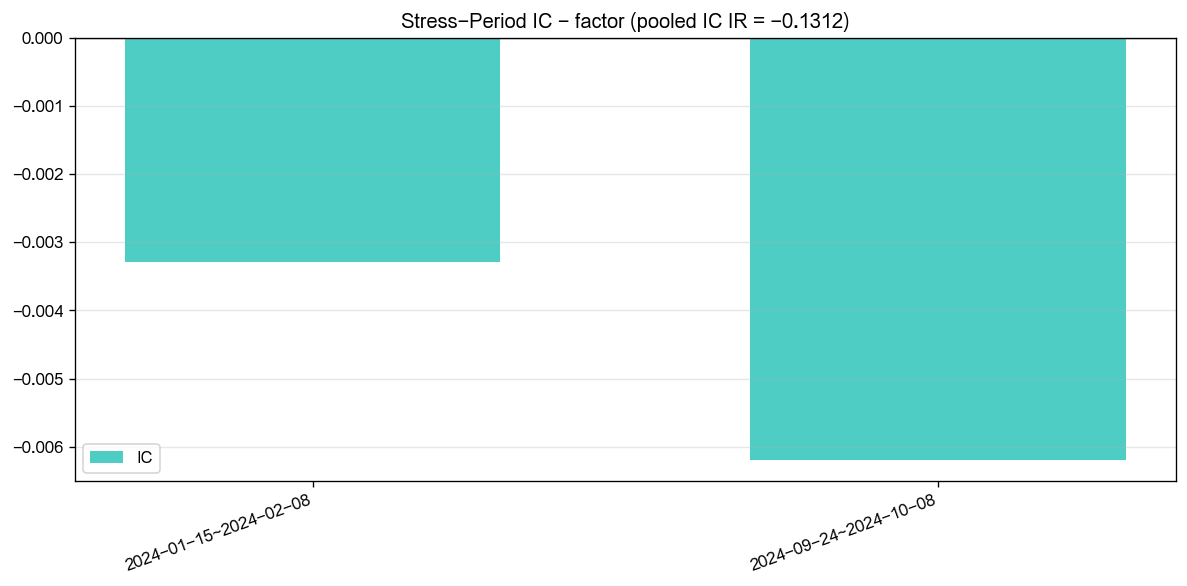
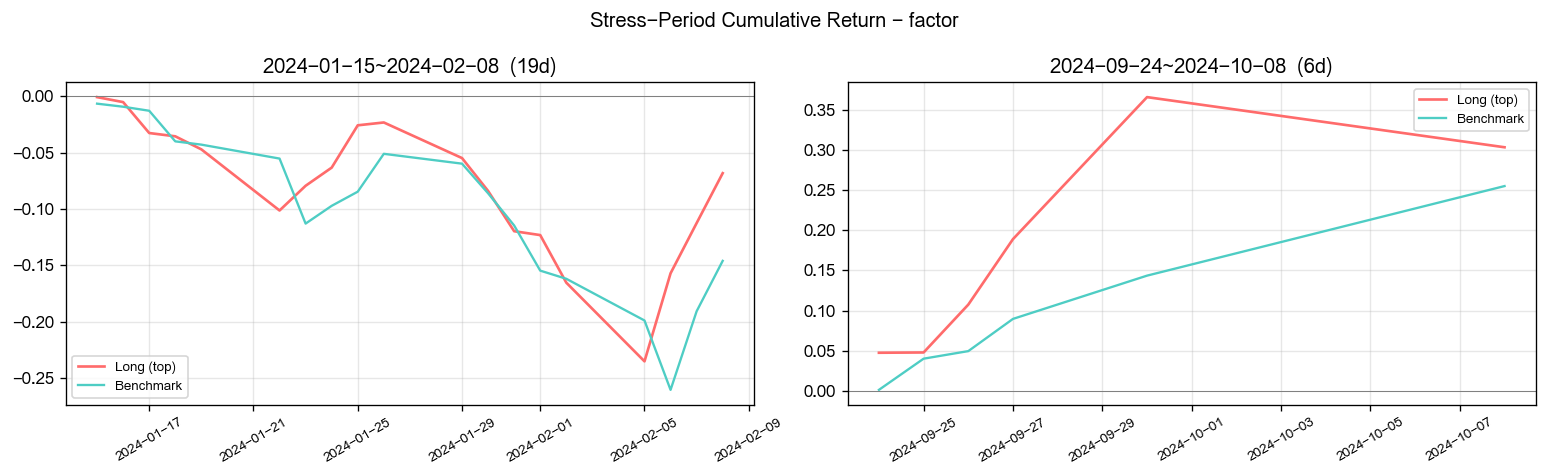

[2026-08-05 13:47:46] [info     ] ========== 因子池回归 ==========
[2026-08-05 13:47:47] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-31 instrument_count=1206 rows=297953 start_date=2024-01-02
[2026-08-05 13:47:48] [info     ] 获取收益率数据, 耗时: 1.6577 秒
[2026-08-05 13:47:49] [info     ] 滚动 Elastic Net 拟合, 耗时: 0.6855 秒
[2026-08-05 13:47:49] [info     ] 统计 回归结果, 耗时: 0.0221 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,rsi_12,1.9235,0.0446,0.0232,1.0000
2,factor,1.8822,0.0066,0.0035,1.0000
3,amount,1.7010,0.0182,0.0107,0.9000
4,netflow_amount_rate_main,1.5396,0.0100,0.0065,1.0000
5,net_profit_rate_ttm,1.5282,0.0037,0.0024,0.8000
6,netflow_amount_main,1.5106,0.0252,0.0167,1.0000
7,gross_profit_rate_ttm,1.4599,0.0072,0.0050,0.9000
8,ps_ttm,1.4223,0.0033,0.0023,0.9000
9,pb,1.4142,0.0097,0.0068,1.0000
10,bias_20,1.4013,0.0290,0.0207,0.9000

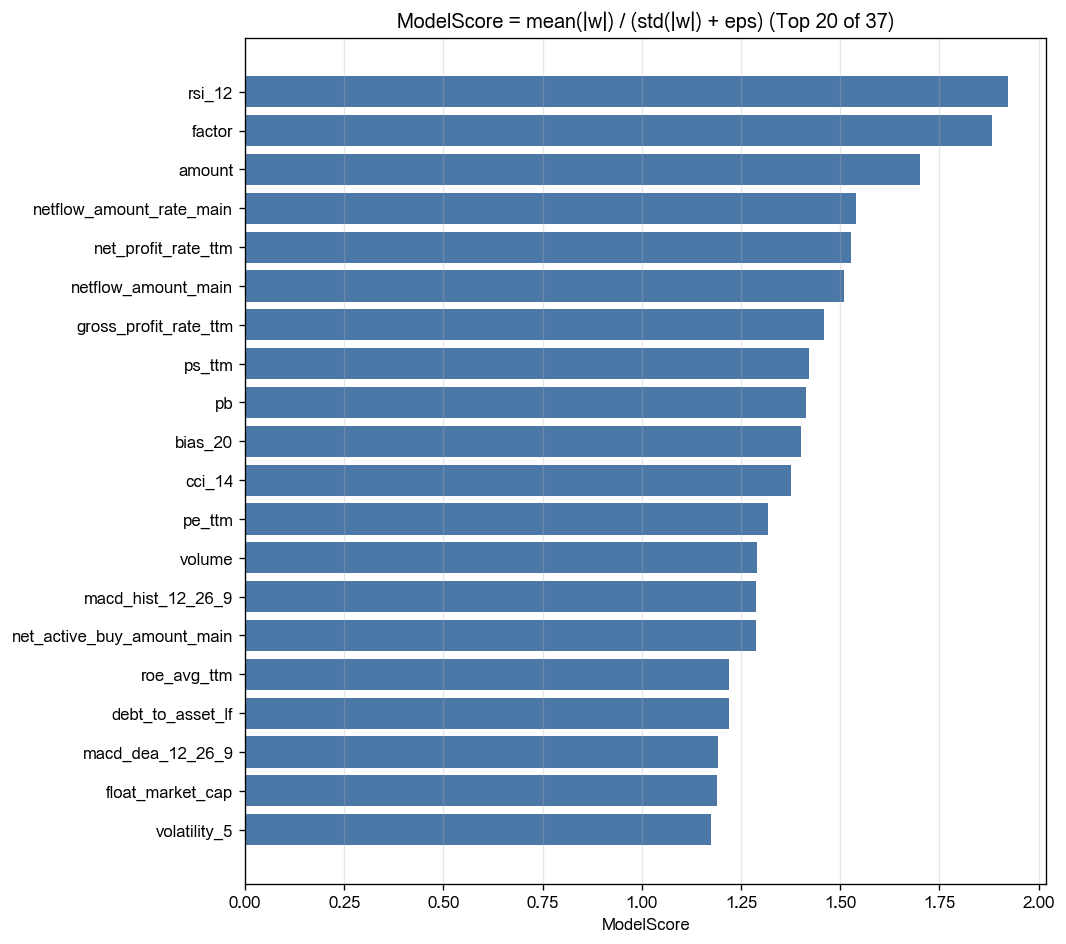
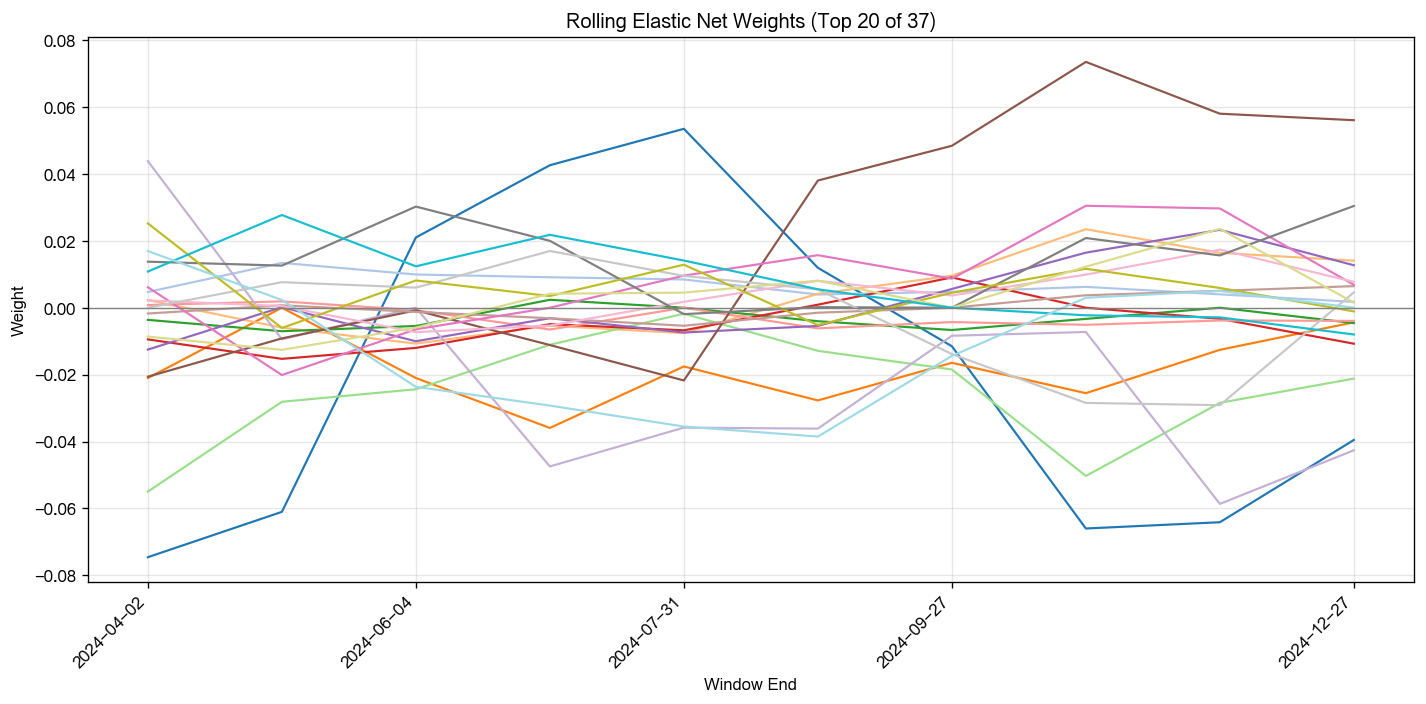
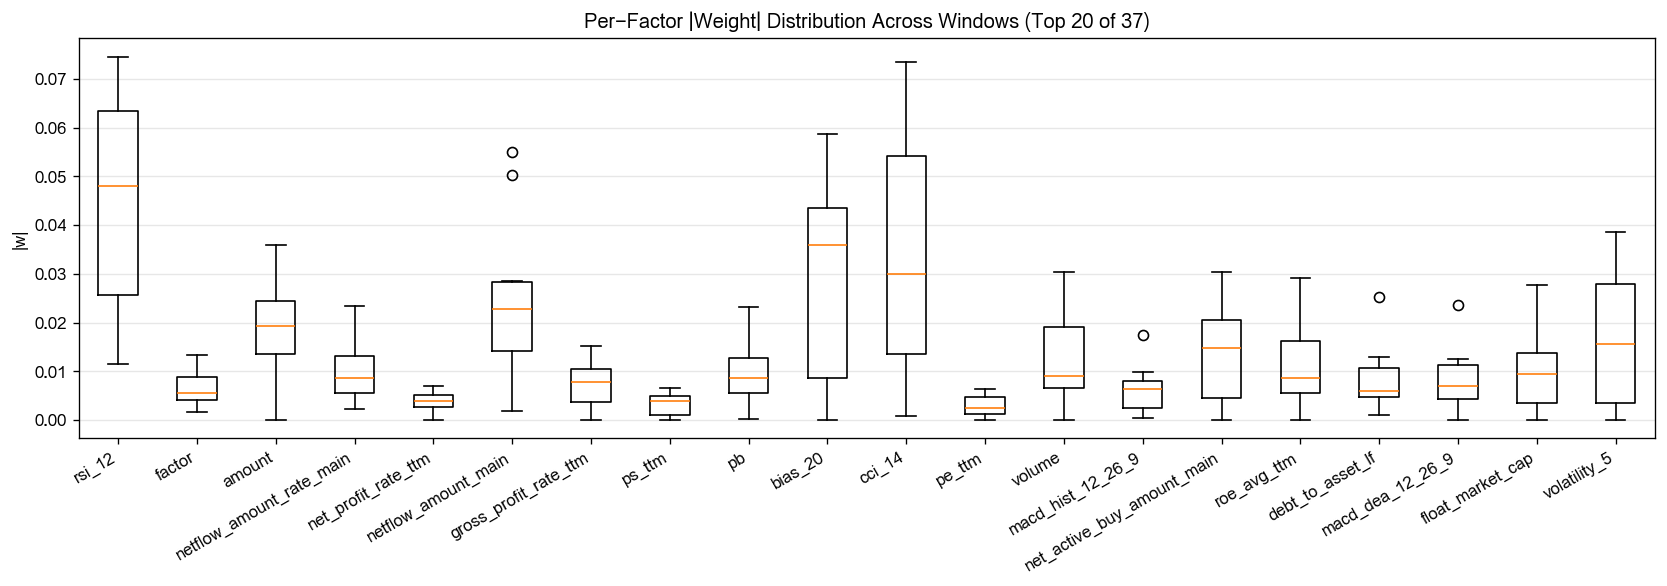
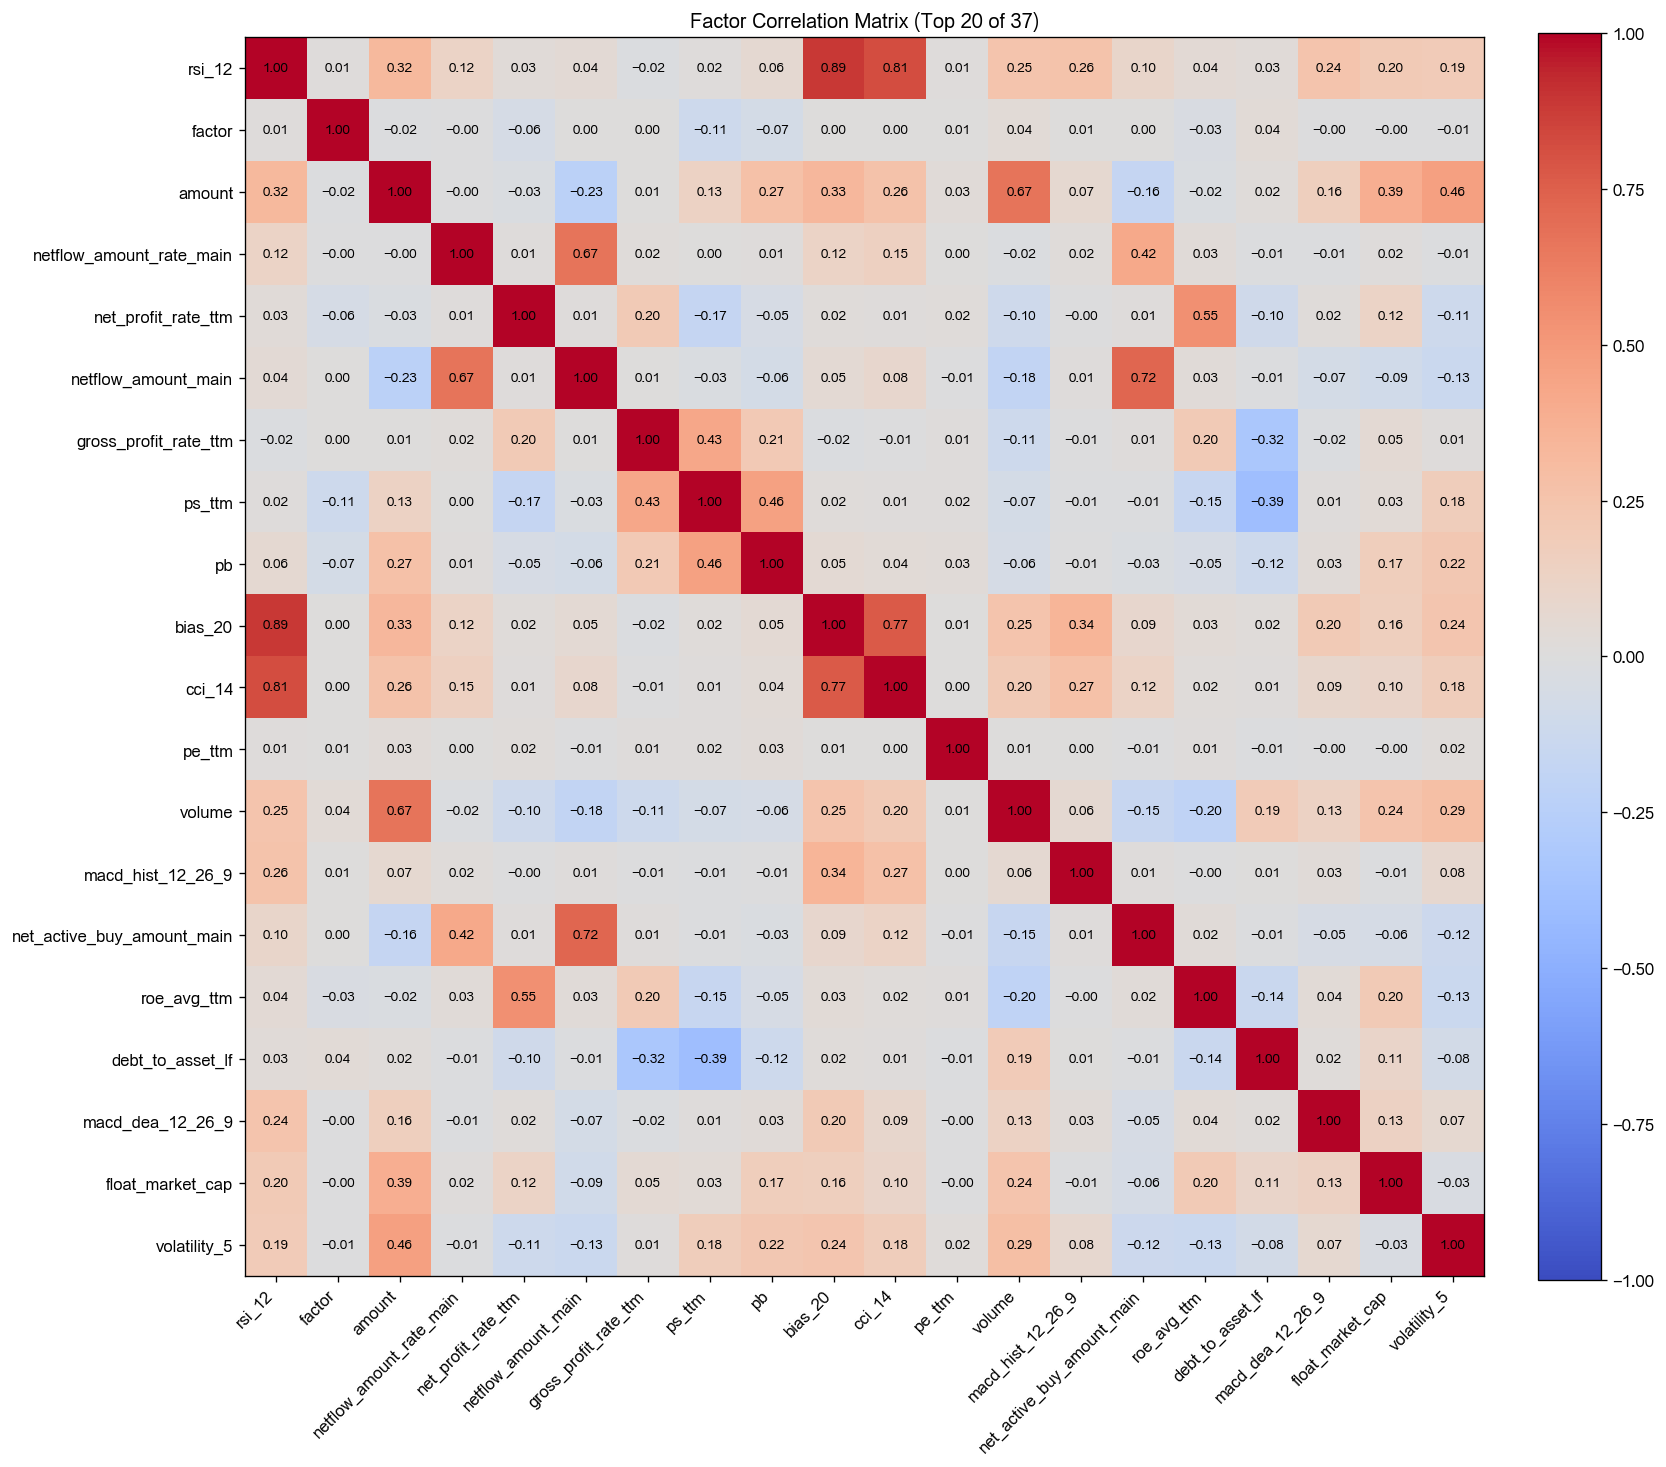

[2026-08-05 13:47:52] [warning  ] 返回的Outputs实例(size=35365181) 大于 64K, 将不会被缓存
[2026-08-05 13:47:52] [info     ] bigalpha_eval.v4 运行完成 [19.771s].


In [1]:
def main(datasources, start_date, end_date):
    """
    因子构建主函数
    评测时平台会自动替换 datasources / start_date / end_date 三个入参并调用本函数
    参数:
        datasources (dict): 数据源表名映射 {逻辑名: 物理表名}
        start_date (str): 开始时间
        end_date (str):   结束时间
    返回:
        pd.DataFrame: 因子数据，须包含三列 ['date', 'instrument', 'factor']，且不含 inf
    """
    import numpy as np
    import pandas as pd
    import dai
    import statsmodels.api as sm

    # --------------------------超参配置--------------------------
    LOOKBACK_DAYS = 730
    MIN_CROSS_SAMPLES = 20
    WINSOR_N = 3
    EPS = 1e-10
    OUTPUT_COLUMNS = ["date", "instrument", "factor"]
    INDUSTRY_TABLE = None

    # --------------------------内嵌通用查询函数--------------------------
    def _query(table_name, fields, left, right):
        try:
            sql = f"SELECT {', '.join(fields)} FROM {table_name}"
            df = dai.query(sql, filters={"date": [left, right]}, compression=True).df()
        except Exception as exc:
            print(f"query_failed table={table_name} err={type(exc).__name__}")
            return pd.DataFrame()
        if df.empty:
            return df
        df["date"] = pd.to_datetime(df["date"], errors="coerce").dt.normalize()
        df["instrument"] = df["instrument"].astype(str)
        df = df.dropna(subset=["date", "instrument"])
        return df.sort_values(["date", "instrument"]).reset_index(drop=True)

    # --------------------------内嵌财务数据加载--------------------------
    def _load_financial(financial_table, query_start, query_end):
        df = _query(
            financial_table,
            [
                "date",
                "instrument",
                "category",
                "shift",
                "cash_paid_for_employees AS cp",
                "operating_costs AS operating_costs",
            ],
            query_start,
            query_end,
        )
        if df.empty:
            return df
        if "category" in df.columns and "shift" in df.columns:
            df["shift"] = pd.to_numeric(df["shift"], errors="coerce")
            df = df[(df["category"] == "ttm") & (df["shift"] == 0)].copy()
        df["cp"] = pd.to_numeric(df["cp"], errors="coerce")
        df["operating_costs"] = pd.to_numeric(df["operating_costs"], errors="coerce")
        df = df.dropna(subset=["cp", "operating_costs"])
        df = df[np.abs(df["operating_costs"]) > EPS]
        df = df.drop_duplicates(["date", "instrument"], keep="last")
        return df[["date", "instrument", "cp", "operating_costs"]].reset_index(drop=True)

    # --------------------------内嵌行业表加载--------------------------
    def _load_industry(query_start, query_end):
        if not INDUSTRY_TABLE:
            return pd.DataFrame()
        df = _query(
            INDUSTRY_TABLE,
            ["date", "instrument", "industry"],
            query_start,
            query_end,
        )
        if df.empty or "industry" not in df.columns:
            return pd.DataFrame()
        df["industry"] = df["industry"].astype(str)
        df = df.drop_duplicates(["date", "instrument"], keep="last")
        return df[["date", "instrument", "industry"]].reset_index(drop=True)

    # --------------------------内嵌asof时序匹配--------------------------
    def _asof_by_instrument(left, right, right_cols):
        if right.empty:
            for col in right_cols:
                left[col] = np.nan
            return left
        keep = ["date", "instrument"] + right_cols
        right = right[keep].sort_values("date").reset_index(drop=True)
        left_sorted = left.sort_values("date").reset_index(drop=True)
        merged = pd.merge_asof(
            left_sorted,
            right,
            on="date",
            by="instrument",
            direction="backward",
        )
        return merged

    # --------------------------分组OLS取残差--------------------------
    def _industry_cross_residual(group):
        group = group.copy()
        valid = group.dropna(subset=["cp", "operating_costs"])
        group["resid_raw"] = np.nan
        if len(valid) < MIN_CROSS_SAMPLES or valid["operating_costs"].std() < 1e-8:
            return group
        try:
            X = sm.add_constant(valid["operating_costs"].values)
            res = sm.OLS(valid["cp"].values, X, missing="drop").fit()
            group.loc[valid.index, "resid_raw"] = res.resid
        except Exception as exc:
            print(f"ols_failed date={group['date'].iloc[0]} err={type(exc).__name__}")
        return group

    # --------------------------MAD‑STD 缩尾处理--------------------------
    def _mad_winsor(series, n=WINSOR_N):
        median = series.median()
        mad = np.median(np.abs(series - median))
        if mad < EPS or pd.isna(mad):
            return series
        upper = median + n * 1.4826 * mad
        lower = median - n * 1.4826 * mad
        return series.clip(lower=lower, upper=upper)

    # --------------------------截面标准化Z‑score--------------------------
    def _cross_zscore(series):
        mu = series.mean(skipna=True)
        sigma = series.std(ddof=0, skipna=True)
        if pd.isna(sigma) or sigma < EPS:
            return pd.Series(0.0, index=series.index)
        return (series - mu) / sigma

    # --------------------------主计算流程--------------------------
    start_ts = pd.Timestamp(start_date).normalize()
    end_ts = pd.Timestamp(end_date).normalize()
    query_start = (start_ts - pd.Timedelta(days=LOOKBACK_DAYS)).strftime("%Y-%m-%d")
    query_end = end_ts.strftime("%Y-%m-%d")

    # 获取动态中证1000券池，和你的第一版模板保持一致
    pool = _query(
        "bigalpha_2026_instruments",
        ["date", "instrument"],
        start_ts.strftime("%Y-%m-%d"),
        query_end,
    )
    if pool.empty:
        return pd.DataFrame(columns=OUTPUT_COLUMNS)
    panel = pool[["date", "instrument"]].drop_duplicates().reset_index(drop=True)

    # 从平台数据源读取财务表
    financial_table = datasources["financial"]
    df_fin = _load_financial(financial_table, query_start, query_end)
    df_ind = _load_industry(query_start, query_end)

    # 财务数据、行业数据时序对齐
    panel = _asof_by_instrument(panel, df_fin, ["cp", "operating_costs"])
    if df_ind.empty:
        panel["industry"] = "global"
    else:
        panel = _asof_by_instrument(panel, df_ind, ["industry"])
        panel["industry"] = panel["industry"].fillna("global")

    # 行业截面OLS回归，研发费用对营业成本取残差
    panel = panel.groupby(["date", "industry"], group_keys=False).apply(_industry_cross_residual)
    # MAD中位数绝对偏差缩尾
    panel["resid_winsor"] = panel.groupby("date")["resid_raw"].transform(_mad_winsor)
    # 每日截面Z‑score标准化得到最终因子
    panel["factor"] = panel.groupby("date")["resid_winsor"].transform(_cross_zscore)
    # 清除inf无穷值、缺失填充，适配平台约束
    panel["factor"] = panel["factor"].replace([np.inf, -np.inf], np.nan).fillna(0.0)

    # 和股票池合并，只保留券池内标的
    result = pool.merge(
        panel[["date", "instrument", "factor"]],
        on=["date", "instrument"],
        how="inner",
    )
    result = result.drop_duplicates(["date", "instrument"], keep="last")
    result["date"] = pd.to_datetime(result["date"]).dt.normalize()
    result["instrument"] = result["instrument"].astype(str)
    result["factor"] = pd.to_numeric(result["factor"], errors="coerce").astype("float32")

    return result[OUTPUT_COLUMNS].sort_values(["date", "instrument"]).reset_index(drop=True)


if __name__ == '__main__':
    from bigmodule import M
    import dai
    import structlog

    logger = structlog.get_logger()

    # 本地自测时自行构造数据源映射（评测时由平台注入，逻辑名固定为 "bar1m"/"financial"）
    datasources = {'bar1m': 'bigalpha_2026_stock_bar1m',
                    'financial':'bigalpha_2026_financial'}
    start_date = '2024-01-01 00:00:00'
    end_date = '2024-12-31 23:59:59'

    # 计算因子
    logger.info(f"计算因子，区间：{start_date} ~ {end_date}")
    factor_data = main(datasources, start_date, end_date)

    # 读取平台因子库用于回归评估
    logger.info(f"读取因子库，区间：{start_date} ~ {end_date}")
    factor_pool = dai.query(
        "SELECT * FROM bigalpha_2026_factorlib",
        filters={'date': [start_date, end_date]},
    ).df()

    # 评估系统
    result = M.bigalpha_eval._latest(
        factor_data=factor_data,
        factor_pool=factor_pool,
        process_pools=False,
        show=True,
    )